# Quantum Error Mitigation Benchmark: Spectral vs. Zero-Noise Extrapolation (ZNE)

This notebook performs a comprehensive comparative analysis between **In-situ Spectral Mitigation** and classical **Zero-Noise Extrapolation (ZNE)** (Linear and Richardson) across multiple quantum circuit families. 

It is structured into a single, cohesive pipeline: defining shared utilities, establishing the mitigation protocols, and executing three core experiments to evaluate performance metrics.

## 1. Setup & Global Configuration
Imports standard libraries, configures the Qiskit environment, and establishes the canonical backend (`FakeManilaV2`) and transpilation options to ensure all circuits are evaluated fairly.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

# Global Backend Configuration
backend = AerSimulator.from_backend(FakeManilaV2())

# Canonical options to ensure consistency between runtime metrics and execution
TRANSPILE_OPTS = dict(
    backend=backend,
    optimization_level=0,  # Preserve structure for accurate ZNE folding
)

def transpile_circuit(qc):
    """Apply global transpilation settings to a quantum circuit."""
    return transpile(qc, **TRANSPILE_OPTS)

def run_counts(qc, shots, seed=None):
    """Execute a logical circuit and return measurement counts."""
    tqc = transpile_circuit(qc)
    return backend.run(tqc, shots=shots, seed_simulator=seed).result().get_counts()


## 2. Shared Utilities & Circuit Definitions
Contains statistical helper functions (probability normalization, dataset splitting, parity expectation) and builders for the three evaluated circuit families: GHZ, QAOA, and Random.

In [2]:
def split_counts(counts, frac, seed=None):
    """Partition a counts dictionary into training and testing subsets."""
    rng = random.Random(seed)
    train, test = {}, {}
    for bitstring, c in counts.items():
        for _ in range(c):
            if rng.random() < frac:
                train[bitstring] = train.get(bitstring, 0) + 1
            else:
                test[bitstring] = test.get(bitstring, 0) + 1
    return train, test

def probs_from_counts(counts, n):
    """Map measurement counts to a probability vector of size 2^n."""
    p = np.zeros(2**n)
    total = sum(counts.values())
    if total == 0:
        return p
    mask = (1 << n) - 1
    for b, c in counts.items():
        idx = int(b[::-1], 2) & mask
        p[idx] += c / total
    return p

def parity_expectation(probs):
    """Calculate the expectation value of the Z-parity operator."""
    return sum(((-1) ** bin(i).count("1")) * p for i, p in enumerate(probs))

def ideal_expectation(qc):
    """Compute the statevector-based exact expectation value."""
    sv = Statevector.from_instruction(qc.remove_final_measurements(inplace=False))
    return parity_expectation(np.abs(sv.data) ** 2)

def circuit_metrics(qc):
    """Retrieve basic circuit properties for annotation."""
    ops = qc.count_ops()
    return {
        "qubits": qc.num_qubits,
        "depth":  qc.depth(),
        "cx":     ops.get("cx", 0),
    }

def ghz(n):
    """Generate a Greenberger-Horne-Zeilinger state."""
    qc = QuantumCircuit(n)
    qc.h(0)
    for i in range(n - 1):
        qc.cx(i, i + 1)
    qc.measure_all()
    return qc

def qaoa_like(n, depth, seed):
    """Generate a QAOA-structured variational circuit with randomized angles."""
    rng = np.random.default_rng(seed)
    qc = QuantumCircuit(n)
    for _ in range(depth):
        for i in range(n):
            qc.rz(rng.uniform(0, 2 * np.pi), i)
        for i in range(n - 1):
            qc.cx(i, i + 1)
    qc.measure_all()
    return qc

def random_family(n, depth, seed):
    """Generate a Haar-random quantum circuit."""
    return random_circuit(n, depth, max_operands=2, measure=True, seed=seed)


## 3. Mitigation Protocols
Implements the logic for classical Zero-Noise Extrapolation (unitary folding and regression) alongside the novel In-situ Spectral Mitigation technique (Walsh-Hadamard entropy calibration).

In [3]:
def fold_circuit(qc, scale):
    """Perform gate-level unitary folding on a logical circuit."""
    assert scale % 2 == 1 and scale >= 1, "Scale factor must be a positive odd integer."
    base = qc.remove_final_measurements(inplace=False)
    folded = QuantumCircuit(base.num_qubits)
    for instruction in base.data:
        inst  = instruction.operation
        qargs = instruction.qubits
        folded.append(inst, qargs)
        for _ in range((scale - 1) // 2):
            if inst.num_qubits == 2:
                folded.append(inst.inverse(), qargs)
                folded.append(inst, qargs)
    folded.measure_all()
    return folded

def zne_linear(scales, values):
    """Apply linear extrapolation to noise-scaled observables."""
    _, b = np.polyfit(scales, values, 1)
    return np.clip(b, -1, 1)

def zne_richardson(scales, values):
    """Apply polynomial (Richardson) extrapolation to noise-scaled observables."""
    coeffs = np.polyfit(scales, values, len(scales) - 1)
    return np.clip(np.poly1d(coeffs)(0.0), -1, 1)

def fwht(a):
    """Fast Walsh-Hadamard Transform."""
    a = np.array(a, float)
    h = 1
    while h < len(a):
        for i in range(0, len(a), h * 2):
            for j in range(i, i + h):
                x, y = a[j], a[j + h]
                a[j], a[j + h] = x + y, x - y
        h *= 2
    return a

def ifwht(a):
    """Inverse Fast Walsh-Hadamard Transform."""
    return fwht(a) / len(a)

class InSituSpectral:
    """Spectral error mitigation using entropy-based calibration."""
    def __init__(self, n):
        self.n  = n
        self.N  = 1 << n
        self.hw = np.array([bin(i).count("1") for i in range(self.N)])
        self.mu = 1.0

    def calibrate(self, probs_train):
        """Optimize the mu parameter using training distribution entropy."""
        spec = fwht(probs_train)
        best_mu, best_score = 1.0, np.inf
        for mu in np.linspace(0.80, 0.99, 25):
            gain  = np.minimum(1.0 / (mu ** self.hw), 50.0)
            clean = ifwht(spec * gain)
            clean = np.clip(clean, 1e-12, None)
            clean /= clean.sum()
            score = -np.sum(clean * np.log(clean)) + 0.01 * np.max(gain)
            if score < best_score:
                best_score, best_mu = score, mu
        self.mu = best_mu

    def mitigate(self, probs):
        """Apply calibrated spectral filters to the target distribution."""
        gain  = np.minimum(1.0 / (self.mu ** self.hw), 50.0)
        clean = ifwht(fwht(probs) * gain)
        clean = np.clip(clean, 0, None)
        return clean / clean.sum()


## 4. Experiment 1: Error Distributions & Circuit Properties
Evaluates overall distribution of absolute error across $15$ randomized trials per circuit family. Generates a box plot and exports tabular physical metrics.


=== Circuit Properties (Transpiled Basis) ===
Family  depth_mean  depth_std  cx_mean  cx_std  q1_mean  q1_std  ideal_mean  ideal_std
   GHZ        7.00       0.00     3.00    0.00     3.00    0.00        1.00       0.00
  QAOA       20.00       0.00    18.00    0.00    24.00    0.00        1.00       0.00
Random       62.60      19.16    25.40   10.74    80.07   20.48        0.16       0.29

=== Mitigation Performance Metrics (MAE) ===
Circuit  Raw MAE  ZNE Linear MAE  ZNE Richardson MAE  Spectral MAE
    GHZ 0.325420        0.310290            0.309723      0.008102
   QAOA 0.349195        0.315256            0.311588      0.020767
 Random 0.087797        0.080983            0.074497      0.022889


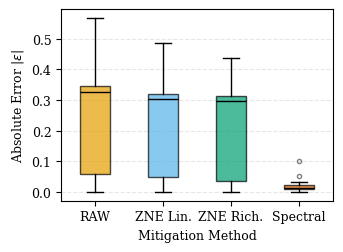

In [5]:
def circuit_metrics_table():
    """Analyze and log physical properties of the benchmark circuits."""
    n, depth, trials = 4, 6, 15
    families = {
        "GHZ":    lambda s: ghz(n),
        "QAOA":   lambda s: qaoa_like(n, depth, s),
        "Random": lambda s: random_family(n, depth, s),
    }

    rows = []
    for name, builder in families.items():
        depths, cx_counts, q1_counts, ideals = [], [], [], []
        for t in range(trials):
            seed = 1000 + t
            qc   = builder(seed)
            tqc  = transpile_circuit(qc)
            ops  = tqc.count_ops()
            
            depths.append(tqc.depth())
            cx_counts.append(ops.get("cx", 0) + ops.get("ecr", 0))
            q1_counts.append(ops.get("sx", 0) + ops.get("x", 0) + ops.get("rz", 0))
            ideals.append(abs(ideal_expectation(qc)))

        rows.append({
            "Family":        name,
            "depth_mean":    np.mean(depths),
            "depth_std":     np.std(depths),
            "cx_mean":       np.mean(cx_counts),
            "cx_std":        np.std(cx_counts),
            "q1_mean":       np.mean(q1_counts),
            "q1_std":        np.std(q1_counts),
            "ideal_mean":    np.mean(ideals),
            "ideal_std":     np.std(ideals),
        })

    df = pd.DataFrame(rows)
    print("\n=== Circuit Properties (Transpiled Basis) ===")
    print(df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
    df.to_csv("circuit_properties.csv", index=False)

def run_benchmark_and_plot():
    """Execute mitigation benchmark and generate comparative visualizations."""
    n, depth, trials = 4, 6, 15
    total_shots = 24_000
    scales = [1, 3, 5]
    shots_per_scale = total_shots // len(scales)

    families = {
        "GHZ":    lambda s: ghz(n),
        "QAOA":   lambda s: qaoa_like(n, depth, s),
        "Random": lambda s: random_family(n, depth, s),
    }

    err_raw_all, err_zne_lin_all, err_zne_rich_all, err_spec_all = [], [], [], []
    rows = []

    for name, builder in families.items():
        err_raw, err_lin, err_rich, err_spec = [], [], [], []
        for t in range(trials):
            seed  = 1000 + t
            qc    = builder(seed)
            ideal = ideal_expectation(qc)

            counts = run_counts(qc, total_shots, seed=seed)
            train_c, test_c = split_counts(counts, 0.5, seed=seed)
            probs_test  = probs_from_counts(test_c,  n)
            probs_train = probs_from_counts(train_c, n)

            # Raw Baseline
            e_raw = abs(parity_expectation(probs_test) - ideal)
            err_raw.append(e_raw); err_raw_all.append(e_raw)

            # Spectral Mitigation
            spec = InSituSpectral(n)
            spec.calibrate(probs_train)
            mitigated = spec.mitigate(probs_test)
            e_spec = abs(parity_expectation(mitigated) - ideal)
            err_spec.append(e_spec); err_spec_all.append(e_spec)

            # ZNE Benchmarking
            vals = []
            for i, s in enumerate(scales):
                c = run_counts(fold_circuit(qc, s), shots_per_scale, seed=seed + i)
                vals.append(parity_expectation(probs_from_counts(c, n)))

            e_lin  = abs(zne_linear(scales, vals) - ideal)
            e_rich = abs(zne_richardson(scales, vals) - ideal)
            err_lin.append(e_lin);   err_zne_lin_all.append(e_lin)
            err_rich.append(e_rich); err_zne_rich_all.append(e_rich)

        rows.append({
            "Circuit":                  name,
            "Raw MAE":                  np.mean(err_raw),
            "ZNE Linear MAE":           np.mean(err_lin),
            "ZNE Richardson MAE":       np.mean(err_rich),
            "Spectral MAE":             np.mean(err_spec),
        })

    df = pd.DataFrame(rows)
    print("\n=== Mitigation Performance Metrics (MAE) ===")
    print(df.to_string(index=False))
    df.to_csv("results.csv", index=False)

    # Plotting Configuration
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 9,
    })

    fig, ax = plt.subplots(figsize=(3.5, 2.6))
    data   = [err_raw_all, err_zne_lin_all, err_zne_rich_all, err_spec_all]
    labels = ["RAW", "ZNE Lin.", "ZNE Rich.", "Spectral"]
    colors = ["#E69F00", "#56B4E9", "#009E73", "#D55E00"]

    ax.grid(True, axis="y", alpha=0.3, linestyle="--")
    bplot = ax.boxplot(data, tick_labels=labels, patch_artist=True,
                       medianprops={"color": "black"},
                       flierprops={"marker": "o", "markersize": 3, "alpha": 0.5})

    for patch, color in zip(bplot["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_ylabel(r"Absolute Error $|\epsilon|$")
    ax.set_xlabel("Mitigation Method")
    plt.tight_layout()

    os.makedirs("fig", exist_ok=True)
    plt.savefig("fig/error_distribution.pdf", dpi=600)
    plt.show()

# Uncomment to execute this block
circuit_metrics_table()
run_benchmark_and_plot()


## 5. Experiment 2: Representative Comparison Grid
Generates a multi-panel visual plotting specific instances of mitigated expectation values directly against the Ideal observable line.

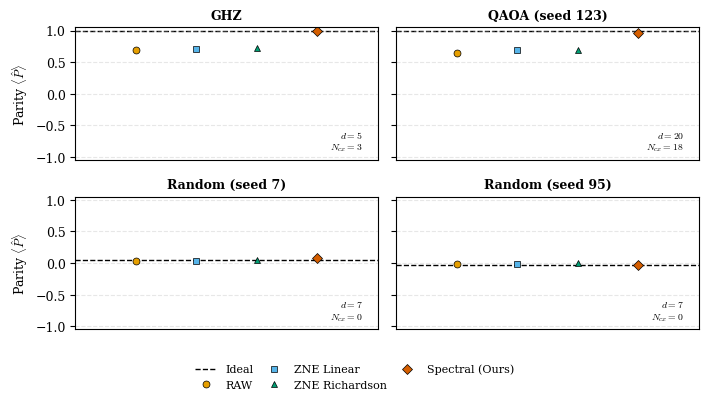

In [7]:
def plot_comparison_grid():
    """Generate comparison plots for specific representative circuit instances."""
    n, depth = 4, 6
    shots    = 24_000
    scales   = [1, 3, 5]
    shots_per_scale = shots // len(scales)

    circuits = [
        ("GHZ",              ghz(n),                         42 ),
        ("QAOA (seed 123)",  qaoa_like(n, depth, seed=123),  123),
        ("Random (seed 7)",  random_family(n, depth, seed=7),   7),
        ("Random (seed 95)", random_family(n, depth, seed=95),  95),
    ]

    plt.rcParams.update({
        "font.family":      "serif",
        "mathtext.fontset": "cm",
        "font.size":        9,
        "axes.grid":        True,
        "grid.alpha":       0.3,
        "grid.linestyle":   "--",
    })

    fig, axes = plt.subplots(2, 2, figsize=(7.16, 4.0), sharey=True)
    axes = axes.flatten()

    colors  = {"id": "#000000", "raw": "#E69F00", "lin": "#56B4E9",
               "rich": "#009E73", "spec": "#D55E00"}
    markers = {"raw": "o", "lin": "s", "rich": "^", "spec": "D"}

    for ax, (label, qc, seed) in zip(axes, circuits):
        ideal = ideal_expectation(qc)

        # Baseline and Spectral processing
        counts  = run_counts(qc, shots, seed=seed)
        train_c, test_c = split_counts(counts, 0.5, seed)
        probs_train = probs_from_counts(train_c, n)
        probs_test  = probs_from_counts(test_c,  n)
        raw_val = parity_expectation(probs_test)

        spec = InSituSpectral(n)
        spec.calibrate(probs_train)
        spec_val = parity_expectation(spec.mitigate(probs_test))

        # ZNE processing
        vals = [
            parity_expectation(
                probs_from_counts(
                    run_counts(fold_circuit(qc, s), shots_per_scale, seed=seed + i), n
                )
            ) for i, s in enumerate(scales)
        ]
        zne_lin  = zne_linear(scales, vals)
        zne_rich = zne_richardson(scales, vals)

        # Visualization
        ax.axhline(ideal, color=colors["id"], linestyle="--", label="Ideal", linewidth=1, zorder=1)

        for x, val, m_key, m_lab in [
            (0.2, raw_val,  "raw",  "RAW"),
            (0.4, zne_lin,  "lin",  "ZNE Linear"),
            (0.6, zne_rich, "rich", "ZNE Richardson"),
            (0.8, spec_val, "spec", "Spectral (Ours)"),
        ]:
            ax.plot(x, val, marker=markers[m_key], color=colors[m_key],
                    label=m_lab, linestyle="None", markersize=5,
                    markeredgecolor="black", markeredgewidth=0.5)

        ax.set_title(label, fontsize=9, fontweight="bold")
        ax.set_xticks([])
        ax.set_xlim(0, 1)
        ax.set_ylim(-1.05, 1.05)
        
        if ax in [axes[0], axes[2]]:
            ax.set_ylabel(r"Parity $\langle \hat{P} \rangle$")

        # Metric annotation
        m = circuit_metrics(qc)
        ax.text(0.95, 0.05, f"$d={m['depth']}$\n$N_{{cx}}={m['cx']}$",
                transform=ax.transAxes, fontsize=7, ha="right", va="bottom",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none"))

    # Global legend configuration
    handles, labels_leg = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels_leg, handles))
    fig.legend(by_label.values(), by_label.keys(),
               loc="lower center", ncol=3, frameon=False,
               fontsize=8, columnspacing=0.8)

    plt.tight_layout(rect=[0, 0.12, 1, 1])
    os.makedirs("fig", exist_ok=True)
    plt.savefig("fig/maxer_ieee.pdf", dpi=600, bbox_inches="tight")
    plt.show()

# Uncomment to execute this block
plot_comparison_grid()


## 6. Experiment 3: Error vs. Measurement Budget
Evaluates the absolute error reduction capability of each algorithm strictly as a function of the allowed global shot budget ($M$).

Shots: 512 | ZNE Allocation: 170/scale
Shots: 1024 | ZNE Allocation: 341/scale
Shots: 2048 | ZNE Allocation: 682/scale
Shots: 4096 | ZNE Allocation: 1365/scale
Shots: 8000 | ZNE Allocation: 2666/scale


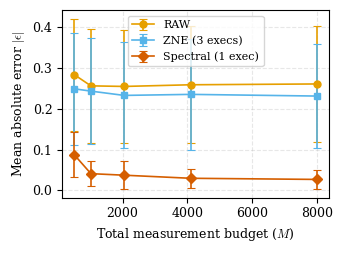

In [9]:
def error_vs_shots():
    """Evaluate mitigation performance across varied sampling budgets."""
    n, depth, trials = 4, 6, 12
    shot_levels = [512, 1024, 2048, 4096, 8000] 
    scales = [1, 3, 5]

    families = {
        "GHZ":    lambda s: ghz(n),
        "QAOA":   lambda s: qaoa_like(n, depth, s),
        "Random": lambda s: random_family(n, depth, s),
    }

    err_raw, err_zne, err_spec = [], [], []
    std_raw, std_zne, std_spec = [], [], []

    for shots in shot_levels:
        per = shots // 3  
        print(f"Shots: {shots} | ZNE Allocation: {per}/scale")

        trial_raw, trial_zne, trial_spec = [], [], []
        for name, build in families.items():
            for t in range(trials):
                seed = 1000 + t
                qc = build(seed)
                ideal = ideal_expectation(qc)

                # Execute baseline/spectral circuit
                c = run_counts(qc, shots, seed=seed)
                tr, te = split_counts(c, 0.5, seed)
                pte = probs_from_counts(te, n)

                # Raw metrics
                trial_raw.append(abs(parity_expectation(pte) - ideal))

                # Spectral Mitigation
                sp = InSituSpectral(n)
                sp.calibrate(probs_from_counts(tr, n))
                trial_spec.append(abs(parity_expectation(sp.mitigate(pte)) - ideal))

                # ZNE Extrapolation
                vals = []
                for i, s in enumerate(scales):
                    cc = run_counts(fold_circuit(qc, s), per, seed=seed + i)
                    vals.append(parity_expectation(probs_from_counts(cc, n)))
                trial_zne.append(abs(zne_linear(scales, vals) - ideal))

        err_raw.append(np.mean(trial_raw));   std_raw.append(np.std(trial_raw))
        err_zne.append(np.mean(trial_zne));   std_zne.append(np.std(trial_zne))
        err_spec.append(np.mean(trial_spec)); std_spec.append(np.std(trial_spec))

    # Visualization Setup
    plt.rcParams.update({
        "font.family":      "serif",
        "mathtext.fontset": "cm",
        "font.size":        9,
        "axes.grid":        True,
        "grid.alpha":       0.3,
        "grid.linestyle":   "--",
    })

    fig, ax = plt.subplots(figsize=(3.5, 2.6))

    ax.errorbar(shot_levels, err_raw, yerr=std_raw, marker="o", color="#E69F00",
                linestyle="-", linewidth=1.2, markersize=5, capsize=3, capthick=0.8, label="RAW")
    ax.errorbar(shot_levels, err_zne, yerr=std_zne, marker="s", color="#56B4E9",
                linestyle="-", linewidth=1.2, markersize=5, capsize=3, capthick=0.8, label="ZNE (3 execs)")
    ax.errorbar(shot_levels, err_spec, yerr=std_spec, marker="D", color="#D55E00",
                linestyle="-", linewidth=1.2, markersize=5, capsize=3, capthick=0.8, label="Spectral (1 exec)")

    ax.set_xlabel(r"Total measurement budget ($M$)")
    ax.set_ylabel(r"Mean absolute error $|\epsilon|$")
    ax.legend(frameon=True, edgecolor="0.8", fontsize=8)
    plt.tight_layout()

    os.makedirs("fig", exist_ok=True)
    plt.savefig("fig/error_vs_shots.pdf", dpi=600, bbox_inches="tight")
    plt.show()

# Uncomment to execute this block
error_vs_shots()


## 7. Hardware Calibration Utilities
Extracts and logs the inherent device metrics of the underlying quantum processor instance. These form the noise baseline for the experiment.

In [11]:
import numpy as np
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

def get_manila_metrics():
    """Extract and print hardware calibration statistics using the modern V2 Target API."""
    backend = FakeManilaV2()
    num_qubits = backend.num_qubits

    t1_times, t2_times, readout_errors = [], [], []
    for q in range(num_qubits):
        # 1. Coherence times via V2 qubit_properties
        q_props = backend.qubit_properties(q)
        t1_times.append(q_props.t1 * 1e6)
        t2_times.append(q_props.t2 * 1e6)
        
        # 2. Readout error via V2 Target for 'measure' instruction
        meas_props = backend.target['measure'].get((q,))
        if meas_props and meas_props.error is not None:
            readout_errors.append(meas_props.error)

    # 3. Gate Fidelity metrics via V2 Target
    sq_errors, cx_errors = [], []
    
    for inst_name in ['sx', 'x']:
        if inst_name in backend.target:
            for qargs, props in backend.target[inst_name].items():
                if props and props.error is not None and props.error > 0:
                    sq_errors.append(props.error)

    if 'cx' in backend.target:
        for qargs, props in backend.target['cx'].items():
            if props and props.error is not None:
                cx_errors.append(props.error)

    print("=== Calibration Snapshot ===")
    print(f"Average T1 Coherence:  {np.mean(t1_times):.2f} us")
    print(f"Average T2 Coherence:  {np.mean(t2_times):.2f} us")
    print(f"Readout Error Range:   [{np.min(readout_errors):.4f}, {np.max(readout_errors):.4f}]")
    print(f"Mean 1Q Gate Error:    {np.mean(sq_errors):.2e}")
    print(f"Mean 2Q Gate Error:    {np.mean(cx_errors):.2e}")

get_manila_metrics()

=== Calibration Snapshot ===
Average T1 Coherence:  147.69 us
Average T2 Coherence:  60.21 us
Readout Error Range:   [0.0144, 0.0964]
Mean 1Q Gate Error:    3.72e-04
Mean 2Q Gate Error:    9.95e-03
